# Setup

In [ ]:
# Installing necessary libraries
!pip install gymnasium
!pip install stable_baselines3

In [ ]:
# Loading all libraries
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/microgrid datasets data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lac Megantic Dataset

In [ ]:
Lac_Megantic_data = pd.read_csv('LacMeganticData.csv') # Load the dataset
Lac_Megantic_data['spot_market_price']=.06095

In [ ]:
Lac_Megantic_data.columns

Index(['Unnamed: 0', 'time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'dew_point_2m (°C)', 'apparent_temperature (°C)', 'precipitation (mm)',
       'rain (mm)', 'snowfall (cm)', 'snow_depth (m)',
       'vapour_pressure_deficit (kPa)', 'et0_fao_evapotranspiration (mm)',
       'cloud_cover_high (%)', 'cloud_cover_mid (%)', 'cloud_cover_low (%)',
       'cloud_cover (%)', 'surface_pressure (hPa)', 'pressure_msl (hPa)',
       'wind_speed_10m (km/h)', 'wind_speed_100m (km/h)',
       'wind_direction_10m (°)', 'wind_direction_100m (°)',
       'wind_gusts_10m (km/h)', 'shortwave_radiation (W/m²)',
       'shortwave_radiation_instant (W/m²)', 'pv_production', 'consumption',
       'spot_market_price'],
      dtype='object')

In [ ]:
Lac_Megantic_data.describe()

,Unnamed: 0,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),snowfall (cm),snow_depth (m),vapour_pressure_deficit (kPa),...,wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),shortwave_radiation (W/m²),shortwave_radiation_instant (W/m²),pv_production,consumption,spot_market_price
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8280.000000,8784.000000,...,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8.784000e+03
mean,4391.500000,6.283732,77.031193,2.146744,3.511305,0.130043,0.096403,0.023652,0.139498,0.297910,...,12.004577,21.315801,215.064663,217.447746,27.015972,150.396516,149.585109,97.936695,228.334111,6.095000e-02
std,2535.866716,10.977782,16.902233,10.796992,13.127662,0.536726,0.503883,0.132976,0.182401,0.371123,...,5.760356,9.207391,83.489592,84.007685,13.033820,225.626771,226.318033,148.175446,85.529923,3.733337e-15
min,0.000000,-22.500000,14.000000,-26.400000,-27.100000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,2.500000,0.000000,0.000000,0.000000,77.605893,6.095000e-02
25%,2195.750000,-1.900000,66.000000,-5.900000,-6.600000,0.000000,0.000000,0.000000,0.000000,0.060000,...,7.900000,15.300000,162.000000,163.000000,16.900000,0.000000,0.000000,0.000000,163.700715,6.095000e-02
50%,4391.500000,6.400000,81.000000,2.500000,3.000000,0.000000,0.000000,0.000000,0.000000,0.150000,...,11.200000,20.600000,239.000000,244.000000,25.200000,7.000000,0.000000,0.000000,212.764345,6.095000e-02
75%,6587.250000,15.400000,90.000000,11.500000,14.500000,0.000000,0.000000,0.000000,0.300000,0.380000,...,15.300000,26.800000,280.000000,282.000000,34.600000,244.250000,238.225000,155.971201,280.001247,6.095000e-02
max,8783.000000,30.900000,100.000000,22.700000,34.700000,16.100000,16.100000,3.430000,0.630000,2.480000,...,43.300000,73.800000,360.000000,360.000000,97.200000,953.000000,955.600000,625.652556,777.483106,6.095000e-02


# Forecasting- Solar and Wind Production

In [ ]:
# class TimeSeriesDataset(Dataset):
#   """
#     Custom PyTorch Dataset class for making Tensor Dataset for Solar/Wind/Load Data
#   """
#   def __init__(self, X, y):
#     self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
#     self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

#   def __len__(self):
#     return len(self.X)

#   def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [ ]:
# class TimeSeriesDataset2(Dataset):
#     """
#     Custom PyTorch Dataset class for Solar/Wind/Load Data
#     """
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

#     def __len__(self):
#         return len(self.X)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]


In [ ]:
# # Helper function to create the datasets
# def create_dataset(data, scaler, input_length=10, TEST_SIZE=0.2, BATCH_SIZE=32):
#   # scale the data
#   #data = scaler.fit_transform(data.to_frame())
#   #data = data.flatten()
#   X, y = [], []
#   # Create samples of input_length previous timestamp data points and predict next data point
#   for i in range(len(data)-input_length):
#     X.append(data[i:i+input_length])
#     y.append(data[i+input_length])

#   # Convert to numpy
#   X = np.array(X)
#   y = np.array(y)

#   # Split the data
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, shuffle=False)

#   # Create datasets
#   train_dataset = TimeSeriesDataset(X_train, y_train)
#   test_dataset = TimeSeriesDataset(X_test, y_test)

#   # Create dataloaders
#   train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#   test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#   return train_loader, test_loader, scaler

In [ ]:
# # Helper function to create the datasets
# def create_dataset_morecols(data, datatype, scaler, input_length=10, TEST_SIZE=0.2, BATCH_SIZE=32):
#   # scale the data
#   #data = scaler.fit_transform(data)
#   X, y = [], []
#   # Create samples of input_length previous timestamp data points and predict next data point
#   for i in range(len(data)-input_length):
#     X.append(data[i:i+input_length])
#     y.append(data[i+input_length, 0])

#   # Convert to numpy
#   X = np.array(X)
#   y = np.array(y)

#   # Split the data
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, shuffle=False)

#   # Create datasets
#   train_dataset = TimeSeriesDataset2(X_train, y_train)
#   test_dataset = TimeSeriesDataset2(X_test, y_test)

#   # Create dataloaders
#   train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
#   test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#   return train_loader, test_loader, scaler

In [ ]:
# # Loading forecasting data- solar, wind and load consumption data
# solar_prod_data = Lac_Megantic_data['pv_production']

# # Creating the scalers
solar_scaler = MinMaxScaler()

# # Create individual data loaders
# solar_train_loader, solar_test_loader, solar_scaler = create_dataset(data=solar_prod_data, scaler=solar_scaler)

In [ ]:
class TransformerForecastingModel(nn.Module):
  """
    Transformer Architecture Time Series Forecasting Model
  """
  def __init__(self, input_dim=1, model_dim=64, output_dim=1, num_heads=4, num_layers=2, dropout=0.1, window_size=24):
      super(TransformerForecastingModel, self).__init__()

      self.embedding = nn.Linear(input_dim, model_dim) # embedding layer
      self.pos_encoder = nn.Parameter(torch.zeros(window_size, model_dim)) # positional encoding
      encoder_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dropout=dropout, batch_first=True) # encoding layer
      self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # transformer layer
      self.fc_out = nn.Linear(model_dim, output_dim) # Fully connected layer for final output

  def forward(self, x):
      x = self.embedding(x)
      x = x + self.pos_encoder.unsqueeze(0) # add positional encodin
      x = self.transformer(x)
      out = x[:, -1, :]  # use last sequence
      out = self.fc_out(out)
      return out

In [ ]:
# # Helper function to evaluate Transformer model
# def evaluate_model(model, scaler, test_loader, datatype):
#   model.eval() # Set model to eval mode
#   prediction = []
#   actual = []
#   # Evaluate on test_loader
#   with torch.no_grad():
#     for X, y in test_loader:
#        pred = model(X)
#        pred = torch.clamp(pred, min=0)
#        prediction.extend(pred.squeeze(-1).numpy())
#        actual.extend(y.squeeze(-1).numpy())

#   prediction=[.9*x for x in prediction]
#   # prediction = scaler.inverse_transform(np.array(prediction).reshape(-1, 1))
#   # actual = scaler.inverse_transform(np.array(actual).reshape(-1, 1))
#   mse = mean_squared_error(actual, prediction)
#   print(f"Test MSE: {mse:.4f}") # Print MSE

  # Print out actual vs prediction for test data
  # plt.figure(figsize=(12, 6))
  # plt.plot(actual, label="Actual", linewidth=2)
  # plt.plot(prediction, label="Predicted", linestyle='--')
  # plt.xlabel("Time Step")
  # plt.ylabel(f"{datatype}Generation (kW or appropriate unit)")
  # plt.title(f"Predicted vs Actual {datatype} Generation")
  # plt.legend()
  # plt.grid(True)
  # plt.tight_layout()
  # plt.show()

  # Zoomed version: first 50 samples
  # plt.figure(figsize=(10, 4))
  # plt.plot(actual[:50], label="Actual")
  # plt.plot(prediction[:50], label="Predicted", linestyle='--')
  # plt.title("Zoomed-in view (first 100 samples)")
  # plt.legend()
  # plt.show()

In [ ]:
# Model Hyperparameters
INPUT_DIM = 1
MODEL_DIM = 64
OUTPUT_DIM = 1
HEADS = 4
LAYERS = 2
DROPOUT = 0.1
WINDOW_SIZE = 10

In [ ]:
# Creating Solar Model
# solar_model = TransformerForecastingModel(INPUT_DIM, MODEL_DIM, OUTPUT_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE)
# solar_criterion = nn.MSELoss()
# solar_optim = optim.Adam(solar_model.parameters(), lr=1e-3)

In [ ]:
# Train Solar Forecasting Model
# NUM_EPOCHS = 40
# solar_model.train()
# for epoch in range(NUM_EPOCHS):
#     total_loss = 0
#     for batch_X, batch_y in solar_train_loader:
#         solar_optim.zero_grad()
#         output = solar_model(batch_X)
#         loss = solar_criterion(output, batch_y)
#         loss.backward()
#         solar_optim.step()
#         total_loss += loss.item()
#     print(f"Epoch {epoch+1}, Loss: {total_loss/len(solar_train_loader):.4f}")

In [ ]:
#evaluate_model(solar_model, solar_scaler, solar_test_loader, "Solar") # Testing Solar Model

In [ ]:
#torch.save(solar_model.state_dict(), "solar_transformer.pth") # Saving Solar Model

In [ ]:
solar_model = TransformerForecastingModel(INPUT_DIM, MODEL_DIM, OUTPUT_DIM, HEADS, LAYERS, DROPOUT, WINDOW_SIZE) # Initialize the model object
solar_model.load_state_dict(torch.load("solar_transformer.pth")) # Load the saved weights into the model object

<All keys matched successfully>

# States:

The following are the states allowed for each of the grid components:

**Renewable:** \
           0- Store in Battery only \
           1- Use for Load/Battery \
           2- Sell to Grid \
**Battery:** \
         0- Charge/Idle State \
         1- Use for Load \
         2- Sell to Grid \
**Grid:** \
      0 - Disconnect \
      1- Connect (to Buy) \
      2- Connect (to Sell) \

**Legal Combinations allowed for the microgrid:** \
001, 100, 101, 110, 111, 122, 212

**Combined Actions:** \
Action 0- Renewable Charges Battery + Grid Connected to satisfy load \
Action 1- Renewable Satisfies Load + Battery Charging + Grid Disconnected \
Action 2- Renewable Satisfies Load + Battery Charging + Grid Connected \
Action 3- Renewable and Battery Satisfy Load + Grid Disconnected \
Action 4- Renewable and Battery Satisfy Load + Grid Connected \
Action 5- Renewable Satisfies Load + Battery sells excess to Grid
Action 6- Renewable Sells to Grid + Battery satisfies Load

#No Forecasting Environment

In [ ]:
import matplotlib.pyplot as plt

def simulate_and_plot(env, model, num_days_to_visualize=2):
    state, _ = env.reset()
    done = False

    log = {
        "hour": [],
        "action": [],
        "sold": [],
        "unmet": [],
        "purchased": [],
        "battery": [],
        "price": [],
        "load": [],
        "pv": [],
        "reward": [],
        "battery_status": [],
        "grid_status": [],
        "renewable_status": [],
        "cost": [],
        "grid_energy": []
    }

    steps_to_visualize = 24 * num_days_to_visualize

    for _ in range(steps_to_visualize):
        action, _ = model.predict(state, deterministic=True)
        next_state, reward, done, _, info = env.step(action)

        for key in log:
            if key == "reward":
                log["reward"].append(reward)
            else:
                log[key].append(info[key])

        state = next_state
        if done:
            break

    hours = list(range(len(log["action"])))
    plt.figure(figsize=(14, 20))

    plt.subplot(5, 1, 1)
    plt.plot(hours, log["action"], label="Action", marker='o')
    plt.title("Actions Taken Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Action ID")
    plt.grid(True)
    plt.legend()

    plt.subplot(5, 1, 2)
    plt.plot(hours, log["sold"], label="Sold to Grid")
    plt.plot(hours, log["purchased"], label="Purchased from Grid")
    plt.plot(hours, log["unmet"], label="Unmet Load")
    plt.plot(hours, log["reward"], label="Reward", linestyle='--', color='black')
    plt.title("Grid Interaction and Reward")
    plt.xlabel("Hour")
    plt.ylabel("Energy / Reward")
    plt.grid(True)
    plt.legend()

    plt.subplot(5, 1, 3)
    plt.plot(hours, log["pv"], label="PV Production")
    plt.plot(hours, log["load"], label="Load")
    plt.plot(hours, log["battery"], label="Battery Level")
    plt.plot(hours, log["price"], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    plt.subplot(5, 1, 4)
    plt.plot(hours[:72], log["pv"][:72], label="PV Production")
    plt.plot(hours[:72], log["load"][:72], label="Load")
    plt.plot(hours[:72], log["battery"][:72], label="Battery Level")
    plt.title("State Variables Over Time (first 72 hours)")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    plt.subplot(5, 1, 5)
    plt.plot(hours[:72], log["price"][:72], label="Spot Market Price", linestyle='--')
    plt.title("State Variables Over Time (first 72 hours)")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    # Map string statuses to numeric values for plotting
    battery_status_map = {
        "Charge/Idle Mode": 0,
        "Discharge Mode": 1,
        "Discharge Sell Mode": 2
    }
    grid_status_map = {
        "Connected": 0,
        "Island Mode": 1
    }
    renewable_status_map = {
        "Satisfy Load and Battery": 0,
        "Charge Battery only": 1,
        "Sell to Grid": 2
    }

    battery_status_vals = [battery_status_map.get(s, -1) for s in log["battery_status"]]
    grid_status_vals = [grid_status_map.get(s, -1) for s in log["grid_status"]]
    renewable_status_vals = [renewable_status_map.get(s, -1) for s in log["renewable_status"]]

    plt.figure(figsize=(14, 10))
    plt.subplot(3, 1, 1)
    plt.plot(hours, battery_status_vals, label="Battery Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Charge/Idle Mode", "Discharge Mode", "Discharge Sell Mode"])
    plt.title("Battery Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(hours, grid_status_vals, label="Grid Status", drawstyle='steps-post')
    plt.yticks([0, 1], ["Connected", "Island Mode"])
    plt.title("Grid Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(hours, renewable_status_vals, label="Renewable Status", drawstyle='steps-post')
    plt.yticks([0, 1, 2], ["Satisfy Load and Battery", "Charge Battery only", "Sell to Grid"])
    plt.title("Renewable Status Over Time")
    plt.xlabel("Hour")
    plt.ylabel("Status")
    plt.grid(True)
    plt.legend()


    plt.tight_layout()
    plt.show()

    print(f"Percentage of time in island mode: {100*sum(grid_status_vals)/len(log['hour'])}")
    print(f"Profit {sum(log['cost'])}")
    print(f"% Energy Satisfied by Grid: {sum(log['grid_energy'])/sum(log['load'])*100}")

In [ ]:
# import gymnasium as gym
# import numpy as np
# from gymnasium import spaces

# class LacMeganticEnv(gym.Env):
#   """
#     Custom Microgrid Environment for Rye Microgrid
#   """
#   def __init__(self, data, num_days):
#     super(LacMeganticEnv, self).__init__()
#     # no of hours to simulate
#     self.num_hours = 24 * num_days
#     self.curr_hour = 0
#     self.daily_purchase=0
#     self.price=0.06905

#     # store all necessary data for Rye Microgrid
#     self.data = data

#     # setup battery
#     self.battery_max = 700
#     self.battery_power = 0.5 * self.battery_max # starting at 50%
#     self.charge_efficiency = 1 # how much power is actually drawn/stored (accounts for losses due to transmission)

#     # State consists of PV, Battery, Load and Price
#     self.observation_space = spaces.Box(
#         low=np.array([0, 0, 0, 0], dtype=np.float32),
#         high=np.array([600, self.battery_max, 800, 2], dtype=np.float32), # max states taken from description of data
#         dtype=np.float32
#     )

#     # Action Space: 7 Actions described above
#     self.action_space = spaces.Discrete(7)

#     self.state = self._get_observation()

#   def _get_observation(self):
#     # Returns the state variables
#     curr_data = self.data.loc[self.curr_hour, ['pv_production', 'consumption', 'spot_market_price']]

#     return np.array([curr_data['pv_production'], self.battery_power, curr_data['consumption'], self.price], dtype=np.float32)

#   def step(self, action):
#     # Unpack state
#     pv, battery, load, price = self.state

#     # Set reward and done states
#     reward = 0 # total reward
#     reward_buy = 0 # reward for buying from grid
#     reward_sell = 0 # reward for selling to grid
#     reward_renewable_use = 0 # reward for using renewable energy
#     reward_unused_load = 0 # reward for unused load
#     reward_grid_conn = 0 # reward for connecting/disconnecting to grid
#     reward_buy_factor = 1 # buy factor
#     reward_sell_factor = 1 # sell factor
#     reward_renewable_use_factor = 0.8 # factor for using renewable energy
#     reward_unused_load_factor = 100 # factor for unused load
#     reward_grid_conn_factor = 0.5 # grid connection factor
#     grid_energy_used=0
#     cost=0

#     done = False # done state

#     # Parameters to help visualization
#     consumption = load
#     unmet = 0
#     purchased = 0
#     sold = 0


#     # Action Handling
#     if action == 0: # Use Renewable to charge battery & buy from grid to satisfy load
#       self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv))
#       purchased = consumption
#       grid_energy_used+=consumption
#       unmet = 0 # all energy purchased from grid
#       reward_buy -= purchased * price
#       reward_grid_conn -= 5
#       reward_renewable_use += (pv) * price
#     elif action == 1: # Use Renewable for Load while Battery is also charging and Grid is disconnected
#       if pv >= consumption:
#         unmet = 0 # all demand met
#         reward_grid_conn += 5
#         reward_renewable_use += (pv) * price
#         purchased = 0
#         self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv - consumption))
#       else:
#         unmet = consumption - pv
#         reward_renewable_use += (pv) * price
#         reward_grid_conn += 5
#         reward_unused_load -= unmet * price
#     elif action == 2: # Use Renewable for Load while Battery is charging and Grid is connected
#       if pv >= consumption:
#         unmet = 0 # all demand met
#         reward_renewable_use += (pv) * price
#         reward_grid_conn -= 5
#         purchased = 0
#         self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv - consumption))
#       else:
#         unmet = 0
#         reward_renewable_use += (pv) * price
#         purchased = consumption - pv
#         grid_energy_used+=consumption
#         reward_buy -= (consumption - pv) * price
#         reward_grid_conn -= 5
#     elif action == 3: # Use both Battery & Renewable for Load while grid is disconnected
#       if pv >= consumption:
#         unmet = 0 # all demand met
#         reward_renewable_use += (pv) * price
#         reward_grid_conn += 5
#         purchased = 0
#       else:
#         if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv):
#           unmet = 0
#           purchased = 0
#           self.battery_power -= (consumption - pv)/self.charge_efficiency
#           reward_renewable_use += (pv) * price
#           reward_grid_conn += 5
#         else:
#           unmet = consumption - pv - self.battery_power
#           self.battery_power = 0
#           purchased = 0
#           reward_renewable_use += (pv) * price
#           reward_unused_load -= unmet * price
#           reward_grid_conn += 5
#     elif action == 4: # Use both Battery & Renewable for Load while grid is connected
#       if pv >= consumption:
#         unmet = 0 # all demand met
#         reward_renewable_use += (pv) * price
#         reward_grid_conn -= 5
#         purchased = 0
#       else:
#         if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv):
#           unmet = 0
#           purchased = 0
#           self.battery_power -= (consumption - pv) / self.charge_efficiency
#           reward_renewable_use += (pv) * price
#           reward_grid_conn -= 5
#         else:
#           unmet = 0
#           reward_renewable_use += (pv) * price
#           reward_grid_conn -= 5
#           purchased = consumption - pv
#           grid_energy_used+=consumption
#           reward_buy -= purchased * price
#     elif action == 5: # Use Renewable for Load and Battery to sell to Grid
#       if pv >= consumption:
#         unmet = 0
#         sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
#         self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
#         reward_sell += sold * price
#         reward_grid_conn -= 5
#         reward_renewable_use += (pv) * price
#       else:
#         unmet = consumption - pv
#         sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
#         self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
#         reward_sell += sold * price
#         reward_renewable_use += (pv) * price
#         reward_unused_load -= unmet * price
#         reward_grid_conn -= 5
#     elif action == 6: # Use Renewable to sell and Battery to load
#       if self.battery_power >= consumption / self.charge_efficiency:
#         unmet = 0
#         sold = pv
#         self.battery_power -= consumption / self.charge_efficiency
#         reward_sell += sold * price
#         reward_grid_conn -= 5
#       else:
#         unmet = consumption - self.charge_efficiency * self.battery_power
#         self.battery_power = 0
#         sold = pv
#         reward_sell += sold * price
#         reward_grid_conn -= 5
#         reward_unused_load -= unmet * price

#     # Update state
#     self.curr_hour += 1
#     if self.curr_hour%24==0:
#       self.week_purchase=0
#       self.price=.06905
#     if self.curr_hour >= self.num_hours:
#         done = True

#     self.daily_purchase+=grid_energy_used

#     if self.daily_purchase > 40:
#       self.price=.10652

#     # Calculate reward
#     reward += reward_sell * reward_sell_factor + reward_unused_load * reward_unused_load_factor \
#               + reward_grid_conn * reward_grid_conn_factor + reward_renewable_use * reward_renewable_use_factor \
#               + reward_buy * reward_buy_factor

#     cost+= reward_sell + reward_buy

#     # Calculate status for grid, battery, and renewable
#     grid_status = "Connected"
#     battery_status = "Discharge Mode"
#     renewable_status = "Satisfy Load and Battery"
#     if reward_grid_conn > 0:
#       grid_status = "Island Mode"
  #   if action == 0 or action == 1 or action == 2:
  #     battery_status = "Charge/Idle Mode"
  #   if action == 5:
  #     battery_status = "Discharge Sell Mode"
  #   if action == 0:
  #     renewable_status = "Charge Battery only"
  #   elif action == 6:
  #     renewable_status = "Sell to Grid"

  #   # Update state
  #   self.state = self._get_observation()
  #   return self.state, reward, done, False, {
  #       "sold": sold,
  #       "unmet": unmet,
  #       "purchased": purchased,
  #       "battery": self.battery_power,
  #       "price": price,
  #       "load": load,
  #       "pv": pv,
  #       "action": action,
  #       "hour": self.curr_hour,
  #       "grid_status": grid_status,
  #       "renewable_status": renewable_status,
  #       "battery_status": battery_status,
  #       "grid_energy": grid_energy_used,
  #       "cost": cost
  #   }

  # def reset(self, seed=None, options=None):
  #   # Reset important parameters
  #   super().reset(seed=seed)
  #   self.curr_hour = 0
  #   self.battery_power = 0.5 * self.battery_max
  #   self.state = self._get_observation()
  #   return self.state, {}


In [ ]:
# from stable_baselines3 import PPO
# from stable_baselines3.common.env_util import make_vec_env

# # Create and wrap environment
# nenv = LacMeganticEnv(Lac_Megantic_data, num_days=len(Lac_Megantic_data)//24-1)
# vec_nenv = make_vec_env(lambda: nenv, n_envs=1)

# # Train the PPO agent
# nmodel = PPO("MlpPolicy", vec_env, verbose=1)
# nmodel.learn(total_timesteps=100000)


# # Save the model
# nmodel.save("ppo_microgrid_NF")

In [ ]:
# nmodel.learn(total_timesteps=100000)

In [ ]:
# simulate_and_plot(nenv, nmodel, num_days_to_visualize=len(Lac_Megantic_data)//24)

# Forecasting Environment

In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces

class LacMeganticEnvF(gym.Env):
  """
    Custom Microgrid Environment for Rye Microgrid
  """
  def __init__(self, data, num_days, forecaster, scaler):
    super(LacMeganticEnvF, self).__init__()
    # no of hours to simulate
    self.num_hours = 24 * num_days
    self.curr_hour = 0
    self.daily_purchase=0
    self.price=0.06905

    # store all necessary data for Rye Microgrid
    self.data = data

    # setup battery
    self.battery_max = 700
    self.battery_power = 0.5 * self.battery_max # starting at 50%
    self.charge_efficiency = 1 # how much power is actually drawn/stored (accounts for losses due to transmission)

    self.forecaster=forecaster
    self.forecaster.eval()

    self.scaler=scaler

    # State consists of PV, Battery, Load and Price
    self.observation_space = spaces.Box(
        low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
        high=np.array([600, self.battery_max, 800, 2, 600], dtype=np.float32), # max states taken from description of data
        dtype=np.float32
    )

    # Action Space: 7 Actions described above
    self.action_space = spaces.Discrete(7)

    self.state = self._get_observation()

  def _get_observation(self):
    # Returns the state variables
    curr_data = self.data.loc[self.curr_hour, ['pv_production', 'consumption', 'spot_market_price']]

    pv_history = self.data.loc[max(0, self.curr_hour - 8):self.curr_hour+1, 'pv_production'].values

    pv_history = np.pad(pv_history, (max(0, 10 - len(pv_history)), 0), 'edge')

    #pv_history = self.scaler.transform(pd.DataFrame(pv_history.reshape(-1, 1), columns=['pv_production'])) # create dataframe to match expected input

    forecasted = self.forecaster(torch.tensor(pv_history, dtype=torch.float32).unsqueeze(-1)).detach().numpy()[0][0]
    forecasted=.9*forecasted
    #forecasted =  self.scaler.inverse_transform(forecasted.reshape(-1,1))[0][0]


    return np.array([curr_data['pv_production'], self.battery_power, curr_data['consumption'], self.price, forecasted], dtype=np.float32)

  def step(self, action):
    # Unpack state
    pv, battery, load, price, forecasted = self.state

    # Set reward and done states
    reward = 0 # total reward
    reward_buy = 0 # reward for buying from grid
    reward_sell = 0 # reward for selling to grid
    reward_renewable_use = 0 # reward for using renewable energy
    reward_unused_load = 0 # reward for unused load
    reward_grid_conn = 0 # reward for connecting/disconnecting to grid
    reward_buy_factor = 1 # buy factor
    reward_sell_factor = 1 # sell factor
    reward_renewable_use_factor = 1 # factor for using renewable energy
    reward_unused_load_factor = 100 # factor for unused load
    reward_grid_conn_factor = 100 # grid connection factor
    grid_energy_used=0
    cost=0

    done = False # done state

    # Parameters to help visualization
    consumption = load
    unmet = 0
    purchased = 0
    sold = 0


    # Action Handling
    if action == 0: # Use Renewable to charge battery & buy from grid to satisfy load
      self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv))
      purchased = consumption
      grid_energy_used+=consumption
      unmet = 0 # all energy purchased from grid
      reward_buy -= purchased * price
      reward_grid_conn -= 5
      reward_renewable_use += (pv) * price
    elif action == 1: # Use Renewable for Load while Battery is also charging and Grid is disconnected
      if pv >= consumption:
        unmet = 0 # all demand met
        reward_grid_conn += 5
        reward_renewable_use += (pv) * price
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv - consumption))
      else:
        unmet = consumption - pv
        reward_renewable_use += (pv) * price
        reward_grid_conn += 5
        reward_unused_load -= unmet * price
    elif action == 2: # Use Renewable for Load while Battery is charging and Grid is connected
      if pv >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv) * price
        reward_grid_conn -= 5
        purchased = 0
        self.battery_power = min(self.battery_max, self.battery_power + self.charge_efficiency * (pv - consumption))
      else:
        unmet = 0
        reward_renewable_use += (pv) * price
        purchased = consumption - pv
        grid_energy_used+=consumption
        reward_buy -= (consumption - pv) * price
        reward_grid_conn -= 5
    elif action == 3: # Use both Battery & Renewable for Load while grid is disconnected
      if pv >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv) * price
        reward_grid_conn += 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv)/self.charge_efficiency
          reward_renewable_use += (pv) * price
          reward_grid_conn += 5
        else:
          unmet = consumption - pv - self.battery_power
          self.battery_power = 0
          purchased = 0
          reward_renewable_use += (pv) * price
          reward_unused_load -= unmet * price
          reward_grid_conn += 5
    elif action == 4: # Use both Battery & Renewable for Load while grid is connected
      if pv >= consumption:
        unmet = 0 # all demand met
        reward_renewable_use += (pv) * price
        reward_grid_conn -= 5
        purchased = 0
      else:
        if self.battery_power >= (1.0/self.charge_efficiency) * (consumption - pv):
          unmet = 0
          purchased = 0
          self.battery_power -= (consumption - pv) / self.charge_efficiency
          reward_renewable_use += (pv) * price
          reward_grid_conn -= 5
        else:
          unmet = 0
          reward_renewable_use += (pv) * price
          reward_grid_conn -= 5
          purchased = consumption - pv
          grid_energy_used+=consumption
          reward_buy -= purchased * price
    elif action == 5: # Use Renewable for Load and Battery to sell to Grid
      if pv >= consumption:
        unmet = 0
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price * 0.6
        reward_grid_conn -= 5
        reward_renewable_use += (pv) * price
      else:
        unmet = consumption - pv
        sold = max(0, self.charge_efficiency * (self.battery_power - 0.5 * self.battery_max))
        self.battery_power = self.battery_max * 0.5 if sold > 0 else self.battery_power
        reward_sell += sold * price * 0.6
        reward_renewable_use += (pv) * price
        reward_unused_load -= unmet * price
        reward_grid_conn -= 5
    elif action == 6: # Use Renewable to sell and Battery to load
      if self.battery_power >= consumption / self.charge_efficiency:
        unmet = 0
        sold = pv
        self.battery_power -= consumption / self.charge_efficiency
        reward_sell += sold * price * 0.6
        reward_grid_conn -= 5
      else:
        unmet = consumption - self.charge_efficiency * self.battery_power
        self.battery_power = 0
        sold = pv
        reward_sell += sold * price * 0.6
        reward_grid_conn -= 5
        reward_unused_load -= unmet * price

    # Update state
    self.curr_hour += 1
    if self.curr_hour%24==0:
      self.week_purchase=0
      self.price=.06905
    if self.curr_hour >= self.num_hours:
        done = True

    self.daily_purchase+=grid_energy_used

    if self.daily_purchase > 40:
      self.price=.10652

    # Calculate reward
    reward += reward_sell * reward_sell_factor + reward_unused_load * reward_unused_load_factor \
              + reward_grid_conn * reward_grid_conn_factor + reward_renewable_use * reward_renewable_use_factor \
              + reward_buy * reward_buy_factor

    cost+= reward_sell + reward_buy

    # Calculate status for grid, battery, and renewable
    grid_status = "Connected"
    battery_status = "Discharge Mode"
    renewable_status = "Satisfy Load and Battery"
    if reward_grid_conn > 0:
      grid_status = "Island Mode"
    if action == 0 or action == 1 or action == 2:
      battery_status = "Charge/Idle Mode"
    if action == 5:
      battery_status = "Discharge Sell Mode"
    if action == 0:
      renewable_status = "Charge Battery only"
    elif action == 6:
      renewable_status = "Sell to Grid"

    # Update state
    self.state = self._get_observation()
    return self.state, reward, done, False, {
        "sold": sold,
        "unmet": unmet,
        "purchased": purchased,
        "battery": self.battery_power,
        "price": price,
        "load": load,
        "pv": pv,
        "action": action,
        "hour": self.curr_hour,
        "grid_status": grid_status,
        "renewable_status": renewable_status,
        "battery_status": battery_status,
        "grid_energy": grid_energy_used,
        "cost": cost
    }

  def reset(self, seed=None, options=None):
    # Reset important parameters
    super().reset(seed=seed)
    self.curr_hour = 0
    self.battery_power = 0.5 * self.battery_max
    self.state = self._get_observation()
    return self.state, {}


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# # Create and wrap environment
env = LacMeganticEnvF(Lac_Megantic_data, num_days=len(Lac_Megantic_data)//24-1, forecaster=solar_model, scaler=solar_scaler)
vec_env = make_vec_env(lambda: env, n_envs=1)

# # Train the PPO agent
# model = PPO("MlpPolicy", vec_env, verbose=1)

model=PPO.load("ppo_microgrid_F", env=vec_env)

In [ ]:
#test data
test=pd.read_csv("LacMeganticDataTest.csv")
test['spot_market_price']=.06095
testenv = LacMeganticEnvF(test, num_days=len(test)//24-1, forecaster=solar_model, scaler=solar_scaler)
vec_testenv = make_vec_env(lambda: testenv, n_envs=1)

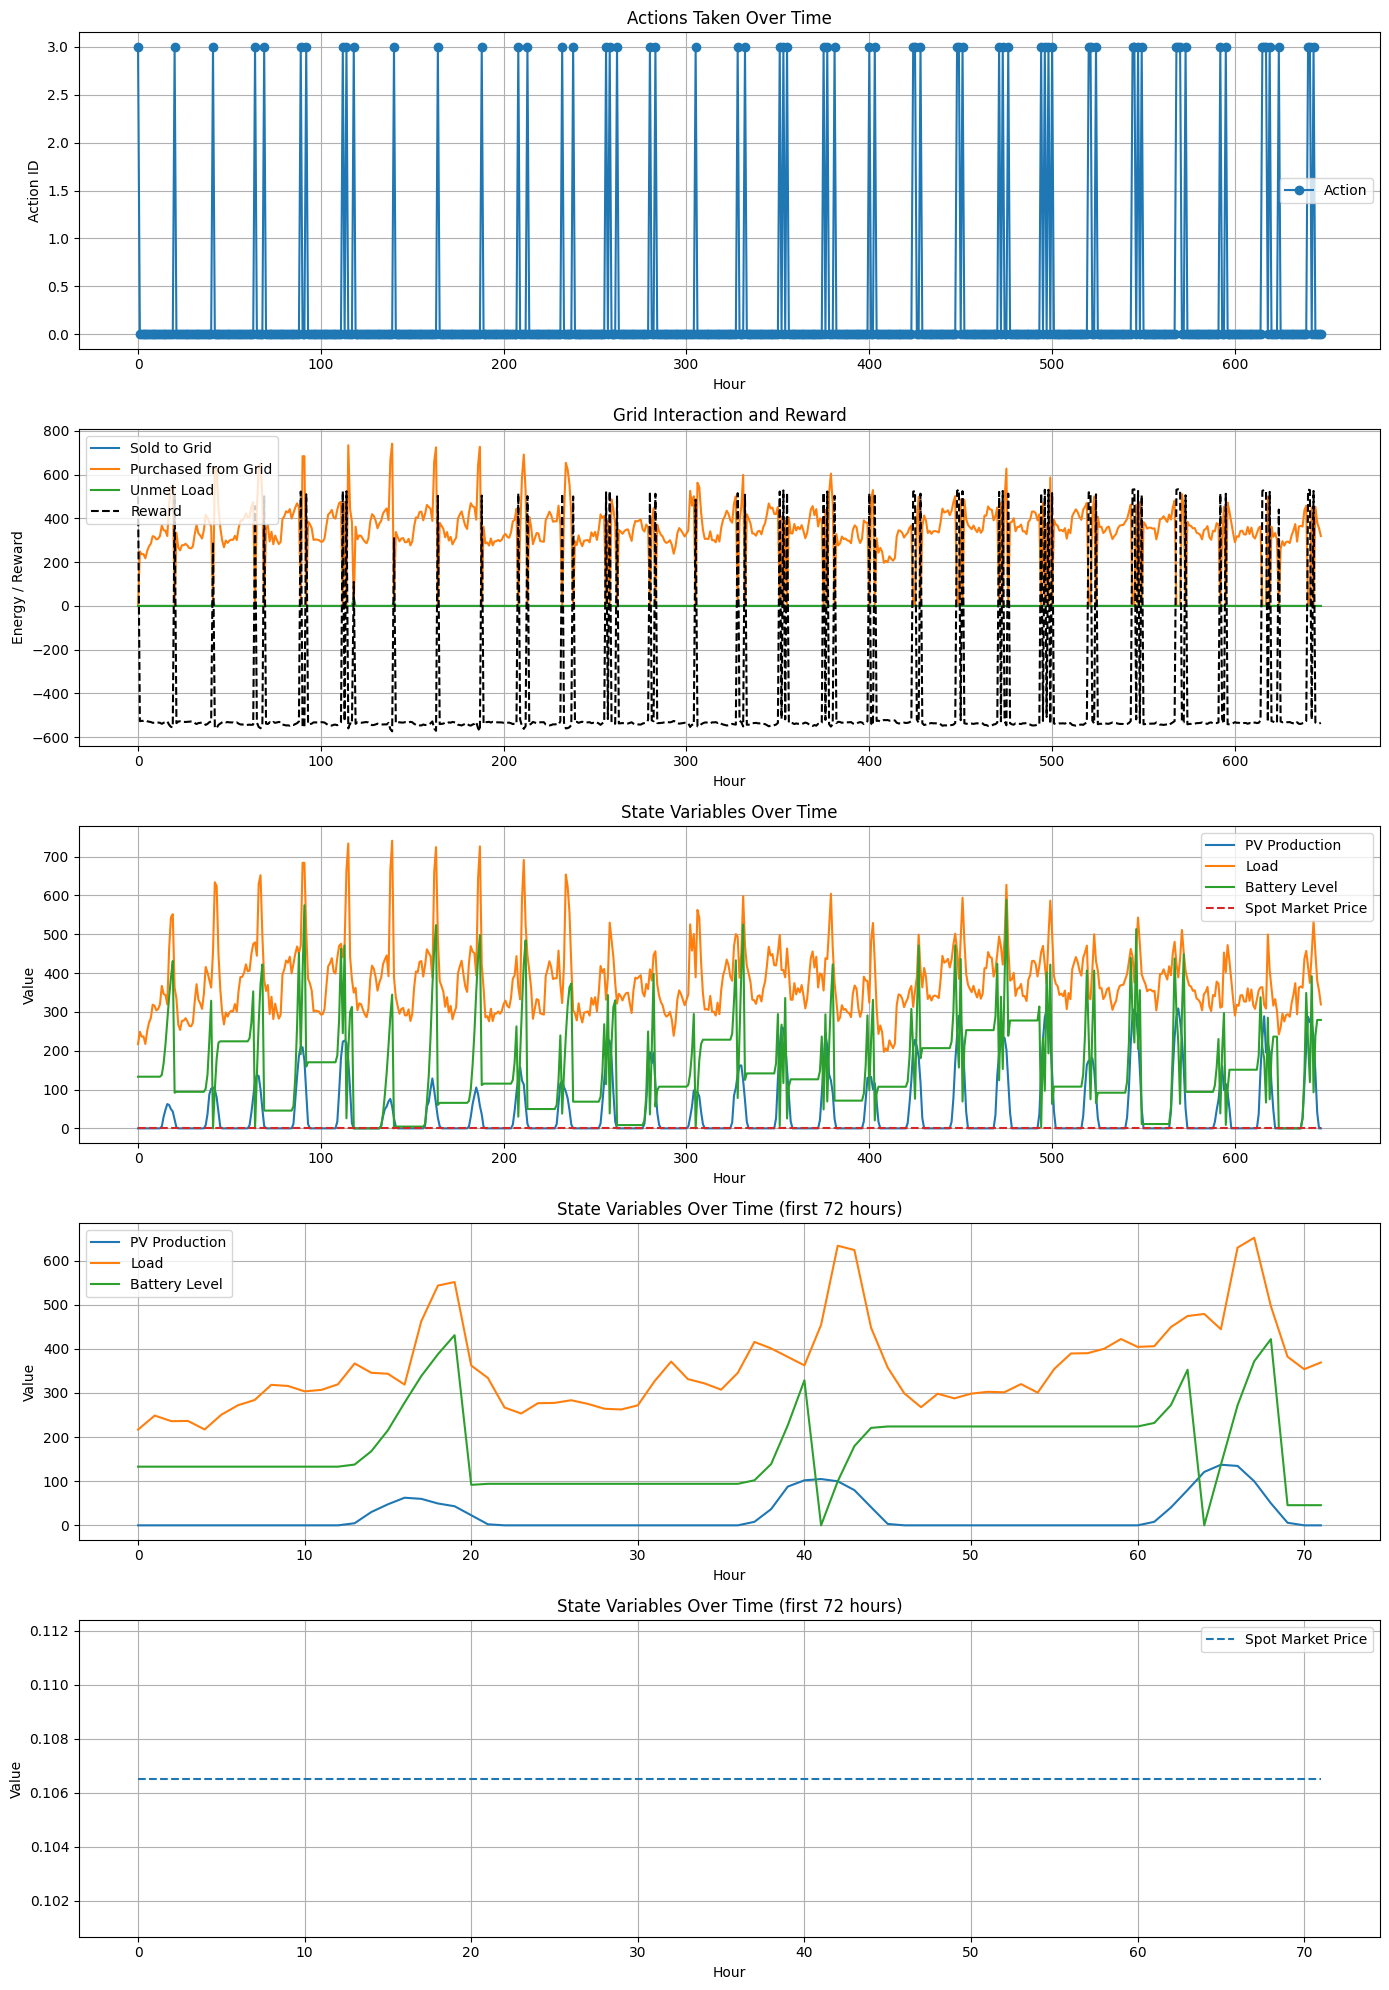

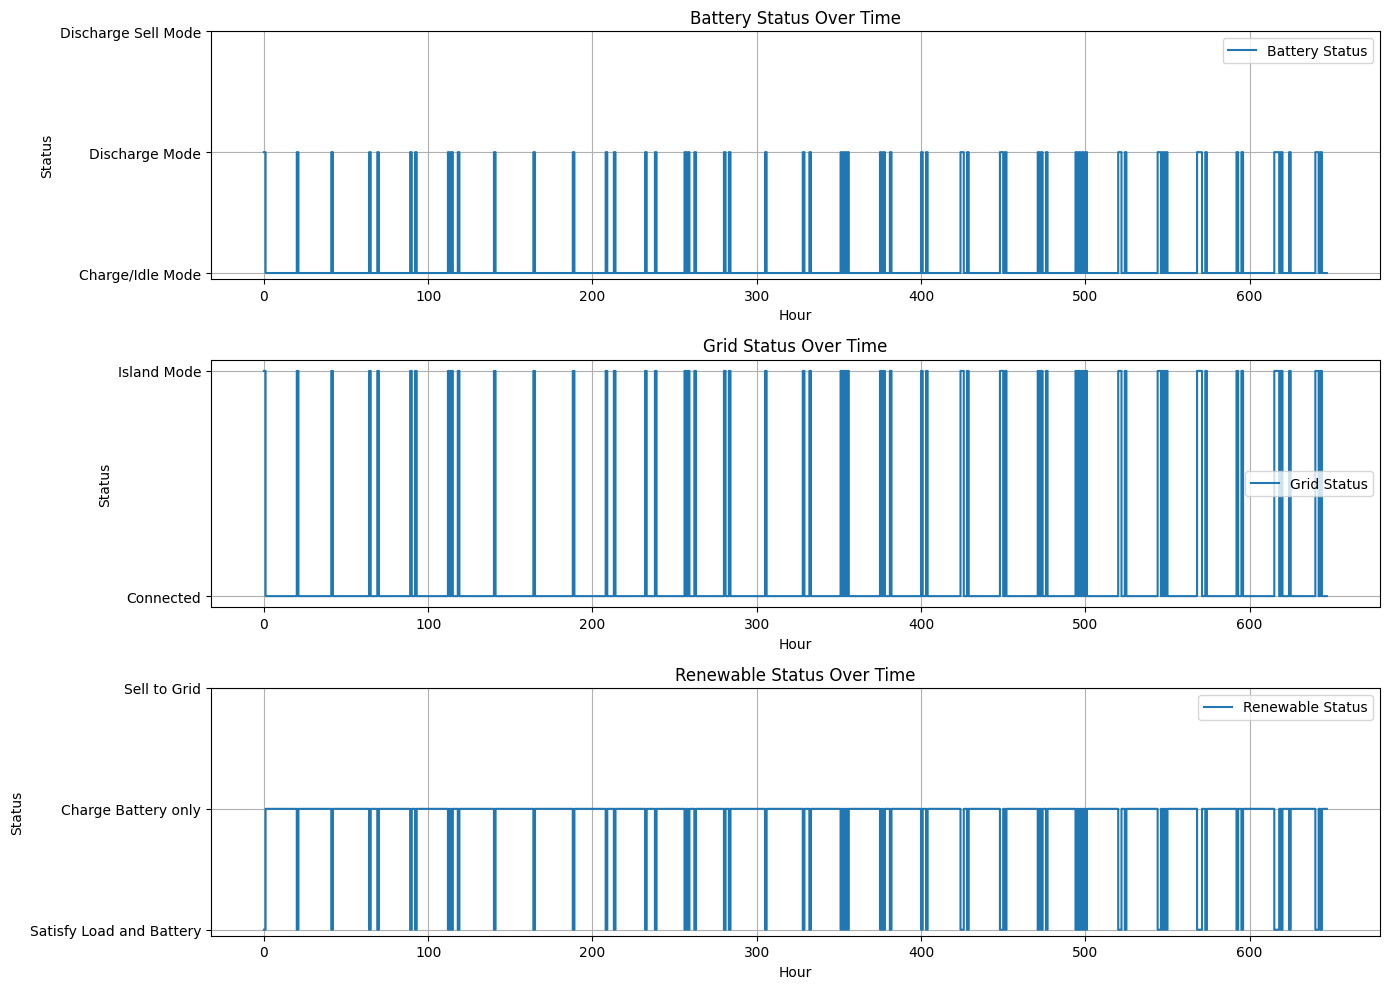

Percentage of time in island mode: 10.339506172839506
Profit -23156.33984375
% Energy Satisfied by Grid: 88.69359588623047


In [ ]:
#model.learn(total_timesteps=1000000)


# # Save the model
#model.save("ppo_microgrid_F")

simulate_and_plot(testenv, model, num_days_to_visualize=len(test)//24)